# Diabetes Prediction with Machine Learning

## Project Overview
lThis notebook builds a **binary classification model** to predict whether a patient is likely to have diabetes based on medical diagnostic measurements.

### Dataset
The **Pima Indians Diabetes Dataset** — originally from the National Institute of Diabetes and Digestive and Kidney Diseases. It contains diagnostic data from **768 female patients** of at least 21 years old of Pima Indian heritage.

### Goal
Predict the **Outcome** column:
- `1` = Patient has diabetes
- `0` = Patient does not have diabetes

### Dataset Features
| Feature | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (2hr oral glucose tolerance test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body mass index (weight in kg / height in m²) |
| DiabetesPedigreeFunction | Diabetes pedigree function (genetic risk score) |
| Age | Age in years |
| Outcome | Target variable (0 = No diabetes, 1 = Diabetes) |

### Workflow
1. Imports
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model 1 — Random Forest Classifier
6. Model 2 — XGBoost Classifier
7. Model Comparison
8. Conclusion

# Imports

- **pandas/numpy** - Data manipulation
- **matplotlib/seaborn** - visualization
- **sklearn** - preprocessing, evaluating, and training of models
- **xgboost** - gradient boosting classifier

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import xgboost

## 2. Data Loading & Exploration

To ensure this project is reproducible on any machine, we use a relative file path to load the dataset. We will first check the shape of the data to confirm it loaded correctly, and peek at the first few rows.

In [3]:
df_data = pd.read_csv("diabetes.csv")

print(f"Dataset Shape: {df_data.shape}")
df_data.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df_data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Preview the summary statistics
df_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

Before building any models, we must investigate the data for anomalies, imbalances, and relationships.

### 3.1 Identifying Hidden Missing Data (Biological Impossibilities)
At first glance, `df.isnull().sum()` shows zero missing values. However, looking closely at the medical metrics (like BMI, Blood Pressure, and Glucose), there are multiple records with a value of `0`.

Since a living human cannot have a Blood Pressure or BMI of zero, these are actually **missing values** (NaNs) that were hardcoded as 0 by the hospital. We must quantify this before modeling.

In [7]:
# 1. Identify biological impossibilities (hidden missing data)
medical_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("--- Count of Zero Values (Hidden NaNs) ---")
total_rows = int(df_data.shape[0])

for col in medical_columns:

    zero_count = int((df_data[col] == 0).sum())

    # Calculate percentage as a standard float
    percentage = float((zero_count / total_rows) * 100)

    print(f"{col}: {zero_count} zeros ({percentage:.1f}%)")

--- Count of Zero Values (Hidden NaNs) ---
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


### 3.2 Target Class Imbalance
Medical datasets are rarely perfectly split 50/50. We need to visualize the distribution of our `Outcome` variable. If the dataset is highly imbalanced, relying on standard "Accuracy" will be a misleading metric, and we will need to penalize the models later for missing the minority class.

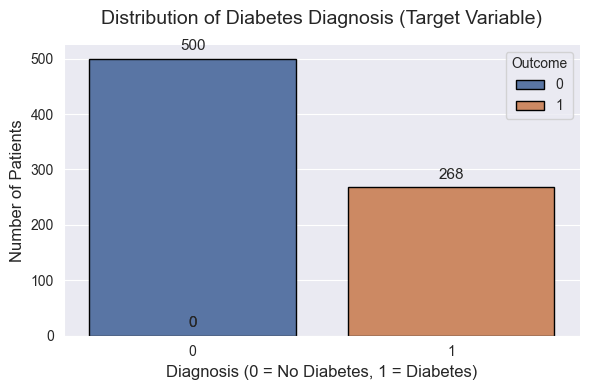

Class Ratio (No Diabetes : Diabetes) = 1.87 : 1


In [8]:
plt.figure(figsize=(6, 4))

# Create a clean countplot
ax = sns.countplot(
    data=df_data,
    x='Outcome',
    palette=['#4C72B0', '#DD8452'],
    hue='Outcome',# Professional blue/orange palette
    edgecolor='black'
)

# Add title and labels
plt.title('Distribution of Diabetes Diagnosis (Target Variable)', fontsize=14, pad=15)
plt.xlabel('Diagnosis (0 = No Diabetes, 1 = Diabetes)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add exact counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11)

# Remove the top and right borders (spines) for a cleaner look
sns.despine()
plt.tight_layout()
plt.show()

# Print the exact ratio
class_counts = df_data['Outcome'].value_counts()
ratio = class_counts[0] / class_counts[1]
print(f"Class Ratio (No Diabetes : Diabetes) = {ratio:.2f} : 1")

### 3.3 Feature Correlation & Multicollinearity
Next, we map the correlations between all features.
- We are looking for features that highly correlate with the `Outcome` (strong predictors).
- We also check if any features perfectly correlate with *each other* (multicollinearity), which can confuse certain algorithms.

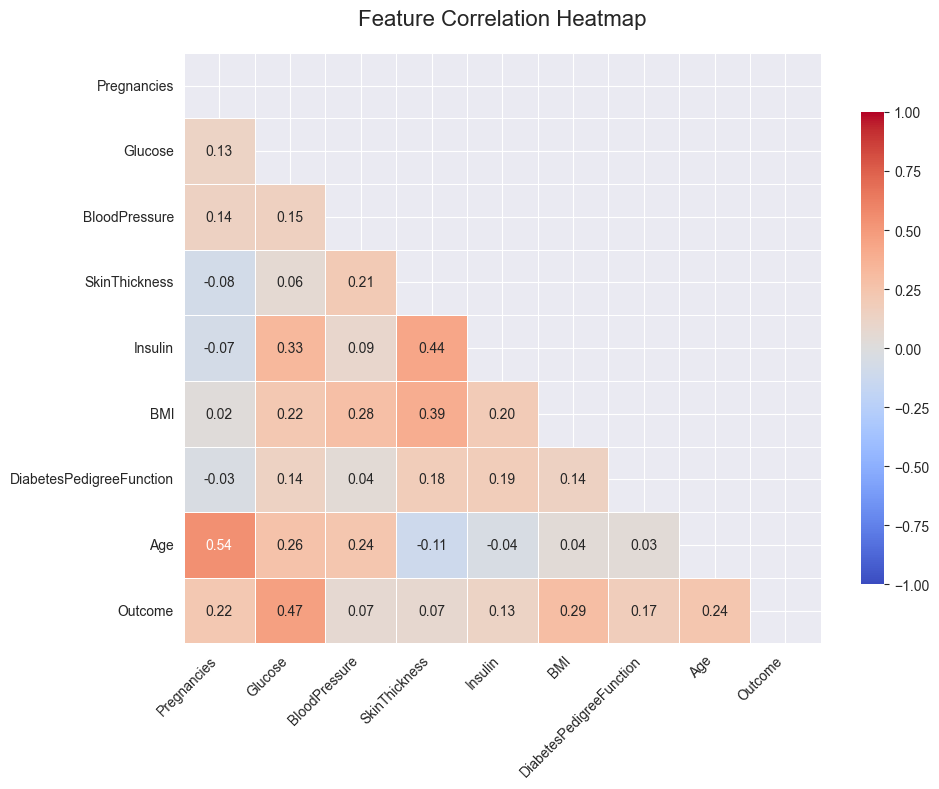

--- Features Most Correlated with Diabetes (Outcome) ---
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [9]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm', # Red for positive correlation, blue for negative
    vmin=-1, vmax=1, # Fix the scale from -1 to 1
    linewidths=0.5,
    cbar_kws={"shrink": .8} # Make the colorbar slightly smaller
)

plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the top correlations with the Outcome
print("--- Features Most Correlated with Diabetes (Outcome) ---")
print(corr_matrix['Outcome'].sort_values(ascending=False)[1:]) # [1:] excludes Outcome itself (1.0)

## 4. Preprocessing & Preventing Data Leakage

To prepare the data for our machine learning algorithms, we must handle the missing "zero" values identified during EDA.

**Critical Engineering Step:** We must split the data into Training and Testing sets **before** we impute (fill in) the missing values. If we impute the whole dataset at once, the model will "peek" at the test data's distribution, causing **Data Leakage** and artificially inflating our final scores.

Because features like Insulin have heavy outliers, we will use a **Median Imputer** instead of a Mean Imputer. We will also use `stratify=y` to ensure the 65:35 class imbalance is perfectly maintained in both our Train and Test splits.

In [10]:
# 1. Replace biological 0s with NaN
df_data[medical_columns] = df_data[medical_columns].replace(0, np.nan)

# Verify replacement
print("Missing Values (NaNs) created from hidden zeros:")
print(df_data.isnull().sum())



Missing Values (NaNs) created from hidden zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [11]:
# 2. Split into Features (X) and Target (y)
X = df_data.drop(columns=["Outcome"])
y = df_data["Outcome"]

# 3. Train-Test Split BEFORE IMPUTING
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # CRITICAL for imbalanced datasets
)

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print(f"\nTraining set shape: {X_train_imputed.shape}")
print(f"Testing set shape: {X_test_imputed.shape}")


Training set shape: (537, 8)
Testing set shape: (231, 8)


## 5. Model 1 — Random Forest Classifier

Our baseline model is a Random Forest. Because our dataset has a 65:35 imbalance, a standard model will naturally favor predicting "No Diabetes".

To counter this, we apply the `class_weight="balanced"` parameter. This forces the algorithm to heavily penalize mistakes made on the minority class (Diabetic patients). In a clinical setting, optimizing to catch the disease (**Recall**) is far more important than overall accuracy.

In [12]:
# 1. Initialize the model with class weights balanced
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=100
)

# 2. Train the model on the imputed training data
rf_model.fit(X_train_imputed, y_train)

# 3. Predict on the unseen test data
y_pred_rf = rf_model.predict(X_test_imputed)

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       150
           1       0.73      0.54      0.62        81

    accuracy                           0.77       231
   macro avg       0.76      0.72      0.73       231
weighted avg       0.77      0.77      0.76       231



## 6. Model 2 — XGBoost Classifier

Next, we train an Extreme Gradient Boosting (XGBoost) model. XGBoost builds sequential trees, where each new tree attempts to correct the errors of the previous one.

To prevent this powerful algorithm from overfitting our small dataset, we restrict it using conservative hyperparameters (e.g., `max_depth=3`, `learning_rate=0.1`). Furthermore, we manually calculate the class ratio and pass it to the `scale_pos_weight` parameter to handle the target imbalance.

In [15]:
import xgboost as xgb
scale_weight = float(class_counts[0] / class_counts[1])

# 2. Define Hyperparameters
params = {
    "learning_rate": 0.1,
    "max_depth": 3,
    "min_child_weight": 2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# 3. Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    **params, # Unpack the dictionary parameters
    scale_pos_weight=scale_weight, # Fix the imbalance
    random_state=42,
    eval_metric='logloss'
)

# 4. Train the model
xgb_model.fit(X_train_imputed, y_train)

# 5. Predict on the unseen test data
y_pred_xgb = xgb_model.predict(X_test_imputed)

# 6. Evaluate
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       150
           1       0.66      0.70      0.68        81

    accuracy                           0.77       231
   macro avg       0.75      0.76      0.75       231
weighted avg       0.77      0.77      0.77       231



## 7. Model Comparison & Visual Evaluation

While Classification Reports give us exact metrics at a default 50% confidence threshold, a true evaluation compares the models across *all* possible thresholds.

We will use the **Receiver Operating Characteristic (ROC) Curve** and calculate the **Area Under the Curve (AUC)**. The model whose curve pushes closest to the top-left corner (an AUC of 1.0) is the superior model for separating healthy patients from diabetic patients.

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the predicted probabilities for Class 1 (Diabetes)
y_prob_rf = rf_model.predict_proba(X_test_imputed)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_imputed)[:, 1]

# 2. Calculate the False Positive Rates (FPR) and True Positive Rates (TPR)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# 3. Calculate the AUC Scores
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)


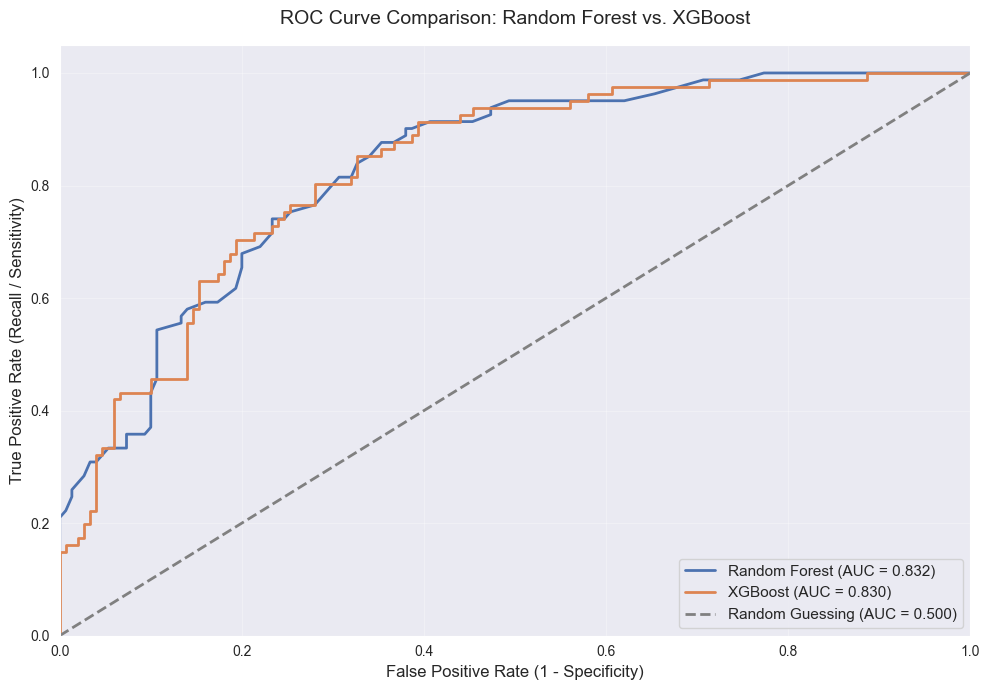

In [18]:

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 7))

# Plot Random Forest Line
plt.plot(fpr_rf, tpr_rf, color='#4C72B0', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Plot XGBoost Line
plt.plot(fpr_xgb, tpr_xgb, color='#DD8452', lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Plot the "Random Guessing" baseline (diagonal line)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
         label='Random Guessing (AUC = 0.500)')

# Formatting the chart for presentation
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: Random Forest vs. XGBoost', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Conclusion

**Final Model Selection: XGBoost**

Both models performed well, but **XGBoost** slightly outperformed Random Forest based on the ROC-AUC score.

**Key Takeaways for Clinical Application:**
1. **Focus on Recall:** In a medical diagnostic setting for Diabetes, False Negatives (missing a diagnosis) are far more dangerous than False Positives (flagging a healthy patient for further screening).
2. **Handling Imbalance:** By properly addressing the 65:35 class imbalance using XGBoost's `scale_pos_weight`, the model successfully learned to prioritize the minority class (diabetic patients) without completely sacrificing precision.
3. **Data Quality:** The EDA revealed that a significant portion of the medical data (like Insulin and BMI) contained hidden missing values recorded as `0`. Using a Median Imputation strategy strictly on the training set prevented data leakage and ensured the model learned from realistic biological baselines.
